In [1]:
import os
from tensorboard.backend.event_processing import event_accumulator
import glob



In [2]:
def get_psnr_and_time_from_tensorboard(logdir_pattern='../output/*', tag='PSNR'):
    psnr_results = {}
    time_results = {}
    for logdir in glob.glob(logdir_pattern):
        print(logdir)
        ea = event_accumulator.EventAccumulator(logdir)
        try:
            ea.Reload()
            print(ea.Tags()['scalars'])
            if tag in ea.Tags()['scalars']:
                psnr_values = [(e.step, e.value) for e in ea.Scalars(tag)]
                psnr_results[logdir] = psnr_values

                scalars = ea.Scalars(tag)
                if scalars:
                    print(scalars)
                    start_time = scalars[0].wall_time
                    end_time = scalars[-1].wall_time
                    time_results[logdir] = end_time - start_time
        except Exception as e:
            print(f"Failed to load {logdir}: {e}")
    return psnr_results, time_results

psnr_data, time_data = get_psnr_and_time_from_tensorboard(tag="render_test/psnr_2d")


In [26]:
def get_psnr_from_yml(logdir_pattern='../output/*'):
    import yaml
    psnr_results = {}
    for base_path in glob.glob(logdir_pattern):
        yml_path = os.path.join(base_path, "test/iter_30000/eval2d_render_test.yml")
        print(yml_path)
        try:
            with open(yml_path, 'r') as f:
                config = yaml.safe_load(f)
                if 'psnr_2d' in config :
                    psnr_results[base_path] = config['psnr_2d']
        except Exception as e:
            print(f"Failed to load {yml_path}: {e}")
            
    return psnr_results

psnr_data = get_psnr_from_yml()

../output/2_backpack_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_engine_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/2_backpack_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/0_jaw_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_teapot_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/1_broccoli_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_beetle_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_bonsai_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/1_bonsai_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/2_present_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/0_head_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_pepper_cone_blu

In [53]:
def get_ssim_from_yml(logdir_pattern='../output/*'):
    import yaml
    psnr_results = {}
    for base_path in glob.glob(logdir_pattern):
        yml_path = os.path.join(base_path, "test/iter_30000/eval2d_render_test.yml")
        print(yml_path)
        try:
            with open(yml_path, 'r') as f:
                config = yaml.safe_load(f)
                if 'ssim_2d' in config :
                    psnr_results[base_path] = config['ssim_2d']
        except Exception as e:
            print(f"Failed to load {yml_path}: {e}")
            
    return psnr_results

ssim_data = get_ssim_from_yml()

../output/2_backpack_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_engine_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/2_backpack_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/0_jaw_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_teapot_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/1_broccoli_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_beetle_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_bonsai_cone_oneshot/test/iter_30000/eval2d_render_test.yml
../output/1_bonsai_cone_blur/test/iter_30000/eval2d_render_test.yml
../output/2_mount_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/2_present_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/0_head_cone_normal/test/iter_30000/eval2d_render_test.yml
../output/1_pepper_cone_blu

In [30]:
for logdir, value in sorted(psnr_data.items()):
    if "oneshot" in logdir:
            name = logdir.split('/')[-1]
            print(f"{name}\t{name.split('_')[1]}\t{value:.3f}")

0_foot_cone_oneshot	foot	32.872
0_head_cone_oneshot	head	37.044
0_jaw_cone_oneshot	jaw	28.098
1_beetle_cone_oneshot	beetle	34.253
1_bonsai_cone_oneshot	bonsai	37.790
1_broccoli_cone_oneshot	broccoli	32.849
1_pepper_cone_oneshot	pepper	37.896
2_backpack_cone_oneshot	backpack	34.401
2_engine_cone_oneshot	engine	31.840
2_mount_cone_oneshot	mount	37.718
2_present_cone_oneshot	present	33.775
2_teapot_cone_oneshot	teapot	39.608


In [56]:
for logdir, value in sorted(ssim_data.items()):
    if "normal" in logdir:
            name = logdir.split('/')[-1]
            print(f"{name}\t{name.split('_')[1]}\t{value:.3f}")

0_foot_cone_normal	foot	0.984
0_head_cone_normal	head	0.996
0_jaw_cone_normal	jaw	0.969
1_beetle_cone_normal	beetle	0.991
1_bonsai_cone_normal	bonsai	0.996
1_broccoli_cone_normal	broccoli	0.991
1_pepper_cone_normal	pepper	0.998
2_backpack_cone_normal	backpack	0.988
2_engine_cone_normal	engine	0.997
2_mount_cone_normal	mount	0.999
2_present_cone_normal	present	0.985
2_teapot_cone_normal	teapot	0.997


In [19]:
for logdir, value in sorted(time_data.items()):
    if "normal" in logdir:
        name = logdir.split('/')[-1]
        m = int((value) // 60)
        s = int(value % 60)
        time_str = f"{m:02}:{s:02}"
        print(f"{name}\t{name.split('_')[1]}\t{step}\t{time_str}")

0_foot_cone_normal	foot	30000	40:37
0_head_cone_normal	head	30000	69:31
0_jaw_cone_normal	jaw	30000	48:56
1_beetle_cone_normal	beetle	30000	19:15
1_bonsai_cone_normal	bonsai	30000	45:15
1_broccoli_cone_normal	broccoli	30000	48:16
1_pepper_cone_normal	pepper	30000	77:22
2_backpack_cone_normal	backpack	30000	31:27
2_engine_cone_normal	engine	30000	59:48
2_mount_cone_normal	mount	30000	118:11
2_present_cone_normal	present	30000	35:16
2_teapot_cone_normal	teapot	30000	26:26


(512, 512) (512, 512) (512, 512)


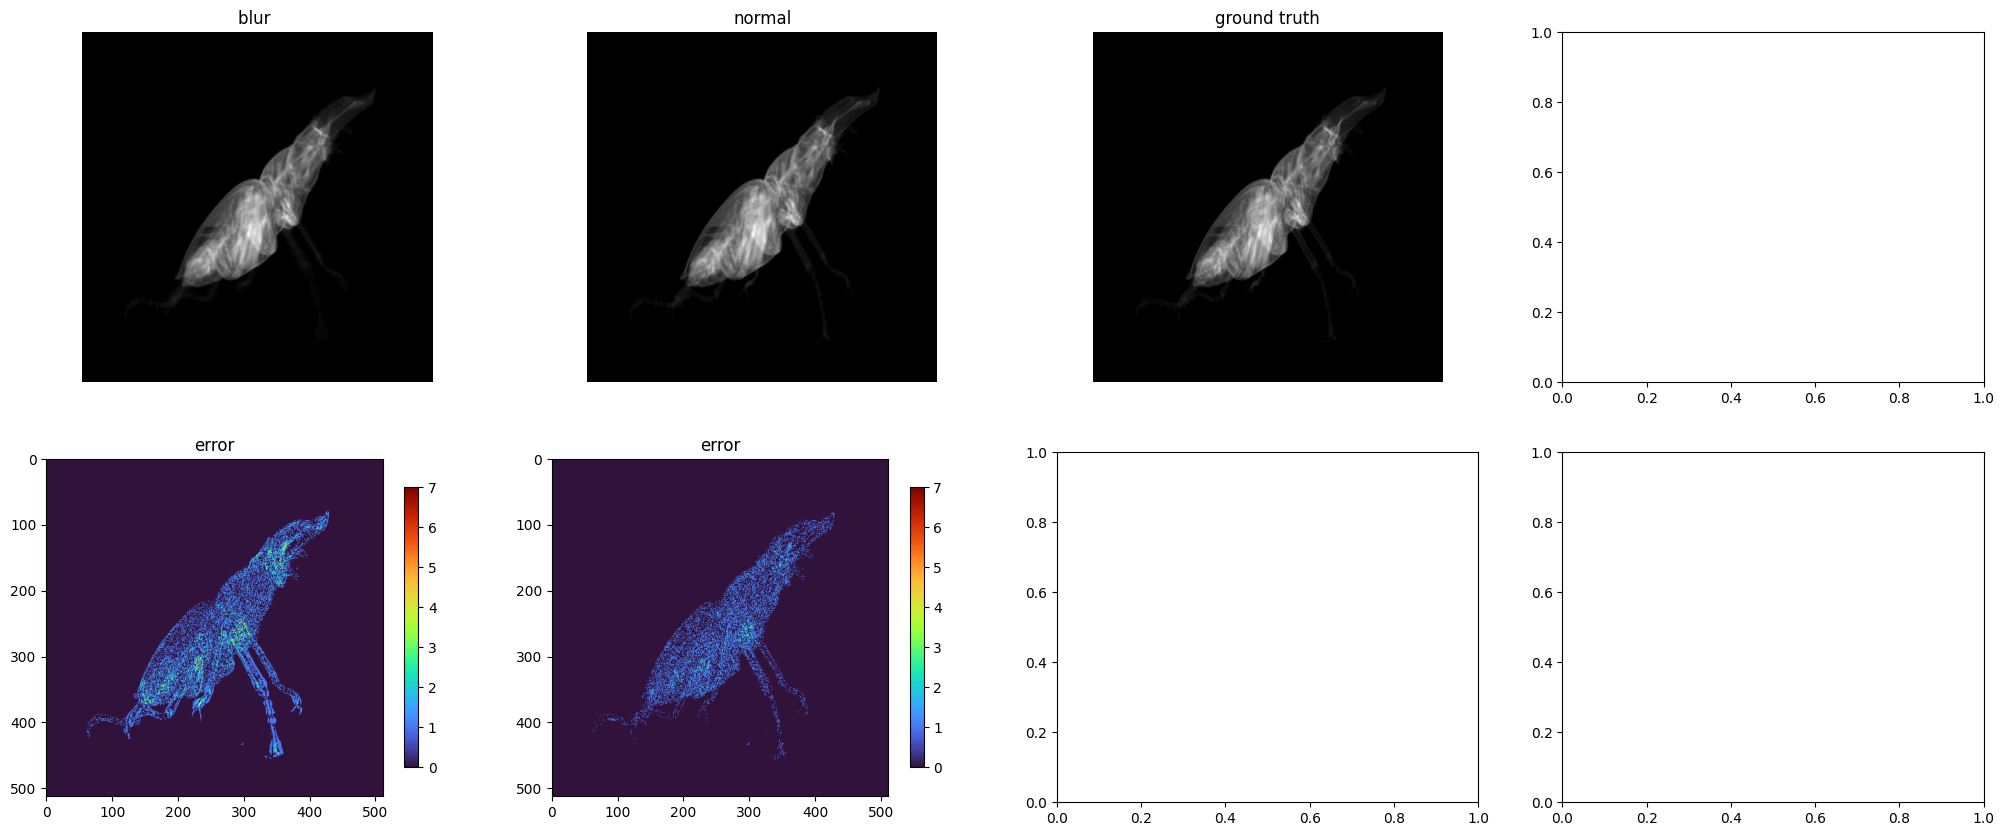

0.09191513061523438
8


In [50]:
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt



dataset = "1_beetle"
# iter = 3000
# iter = 2809000
idx = 9
img_path = f"/home/ryuya/ImariLab/r2_gaussian_deblur/output/{dataset}_cone_blur/test/iter_30000/render_test/{idx:05}_pred.png"
max_img = Image.open(img_path)
max_img_np = np.array(max_img).astype(np.int16)[..., 0]

img_path = f"/home/ryuya/ImariLab/r2_gaussian_deblur/output/{dataset}_cone_normal/test/iter_30000/render_test/{idx:05}_pred.png"
normal_img = Image.open(img_path)
normal_img_np = np.array(normal_img).astype(np.int16)[..., 0]


img_path = f"/home/ryuya/ImariLab/r2_gaussian_deblur/output/{dataset}_cone_normal/test/iter_30000/render_test/{idx:05}_gt.png"
gt_img = Image.open(img_path)
gt_img_np = np.array(gt_img).astype(np.int16)[..., 0]

print(max_img_np.shape, normal_img_np.shape, gt_img_np.shape)

fig, axes = plt.subplots(2, 4, figsize=(25, 10))
axes[0, 0].imshow(max_img_np, cmap="gray")
axes[0, 0].set_title(f"blur ")
axes[0, 0].axis('off')
axes[0, 1].imshow(normal_img_np, cmap="gray")
axes[0, 1].set_title("normal")
axes[0, 1].axis('off')
axes[0, 2].imshow(gt_img_np, cmap="gray")
axes[0, 2].set_title("ground truth")
axes[0, 2].axis('off')
plt.colorbar(axes[1, 0].imshow(np.abs(max_img_np - gt_img_np), cmap="turbo", vmax = np.max(max_img_np - gt_img_np)), ax=axes[1,0], shrink=0.8)
axes[1, 0].set_title("error")
# axes[1, 0].axis('off')

plt.colorbar(axes[1, 1].imshow(np.abs(normal_img_np - gt_img_np), cmap="turbo", vmax = np.max(max_img_np - gt_img_np)), ax=axes[1,1], shrink=0.8)
axes[1, 1].set_title("error")
# axes[1, 1].axis('off')


plt.show()
print(np.abs((max_img_np - gt_img_np)).mean())
print(np.abs((max_img_np - gt_img_np)).max())


In [ ]:
for logdir, value in sorted(time_data.items()):
    if "normal" in logdir:
        name = logdir.split('/')[-1]
        m = int((value) // 60)
        s = int(value % 60)
        time_str = f"{m:02}:{s:02}"
        print(f"{name}\t{name.split('_')[1]}\t{step}\t{time_str}")

0_foot_cone_normal	foot	30000	40:37
0_head_cone_normal	head	30000	69:31
0_jaw_cone_normal	jaw	30000	48:56
1_beetle_cone_normal	beetle	30000	19:15
1_bonsai_cone_normal	bonsai	30000	45:15
1_broccoli_cone_normal	broccoli	30000	48:16
1_pepper_cone_normal	pepper	30000	77:22
2_backpack_cone_normal	backpack	30000	31:27
2_engine_cone_normal	engine	30000	59:48
2_mount_cone_normal	mount	30000	118:11
2_present_cone_normal	present	30000	35:16
2_teapot_cone_normal	teapot	30000	26:26


In [51]:
print(img_np[400, 300], gt_img_np[400, 300], img_np[400, 300]-gt_img_np[400, 300])

-34 -35 1


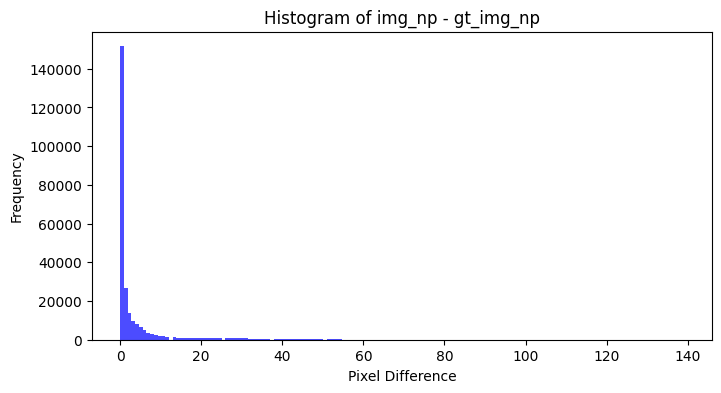

In [91]:
plt.figure(figsize=(8, 4))
plt.hist(np.abs(max_img_np - gt_img_np).ravel(), bins=150, color='blue', alpha=0.7)
plt.title("Histogram of img_np - gt_img_np")
plt.xlabel("Pixel Difference")
plt.ylabel("Frequency")

plt.show()

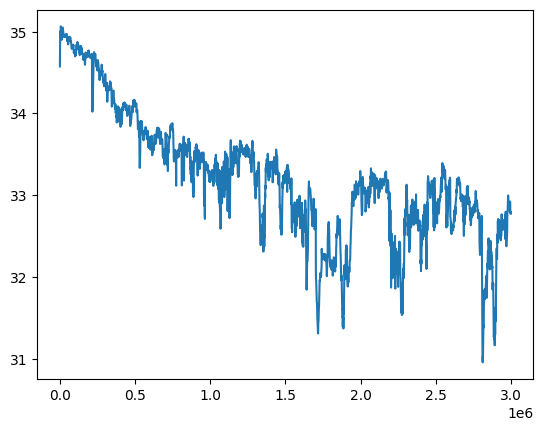

In [97]:
psnr_list = []
for iter in range(1000, 3000000, 1000):
    info_path = f"/home/ryuya/ImariLab/r2_gaussian_deblur/output/old/bonsai_blur_300000/eval/iter_{iter:06}/eval2d_render_test.yml"
    with open(info_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if "psnr_2d" in line:
                psnr = float(line.split(":")[-1].strip())
                # print(f"Iteration {iter}: PSNR={psnr}")
                psnr_list.append(psnr)
                break
plt.plot(list(range(1000, 3000000, 1000)), psnr_list)

Iteration 2890000: PSNR=39.48564529418945
Iteration 2890000: PSNR=30.695398330688477
Iteration 2890000: PSNR=40.56529235839844
Iteration 2890000: PSNR=33.58592224121094
Iteration 2890000: PSNR=37.15697479248047
Iteration 2890000: PSNR=38.66836929321289
Iteration 2890000: PSNR=37.86369705200195
Iteration 2890000: PSNR=26.359216690063477
Iteration 2890000: PSNR=32.95518493652344
Iteration 2890000: PSNR=26.253013610839844
Iteration 2890000: PSNR=29.24861717224121
Iteration 2890000: PSNR=36.822509765625
Iteration 2890000: PSNR=25.956335067749023
Iteration 2890000: PSNR=30.690784454345703
Iteration 2890000: PSNR=30.74755859375
Iteration 2890000: PSNR=27.157018661499023
Iteration 2890000: PSNR=26.39037322998047
Iteration 2890000: PSNR=25.041927337646484
Iteration 2890000: PSNR=25.255477905273438
Iteration 2890000: PSNR=30.258665084838867
Iteration 2890000: PSNR=32.23109436035156
Iteration 2890000: PSNR=32.6230354309082
Iteration 2890000: PSNR=33.9989013671875
Iteration 2890000: PSNR=34.72970

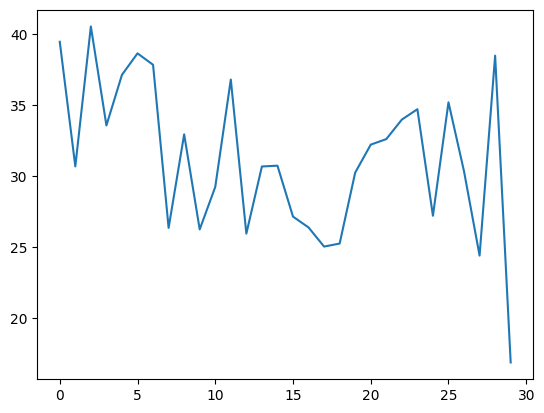

In [101]:
psnr_list = []
iter = 2890000
info_path = f"/home/ryuya/ImariLab/r2_gaussian_deblur/output/old/bonsai_blur_300000/eval/iter_{iter:06}/eval2d_render_test.yml"
with open(info_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        if "ssim_2d_projs:" in line:
            break
        if "-" in line:
            psnr = float(line.split()[-1].strip())
            print(f"Iteration {iter}: PSNR={psnr}")
            psnr_list.append(psnr)
plt.plot(range(len(psnr_list)), psnr_list)